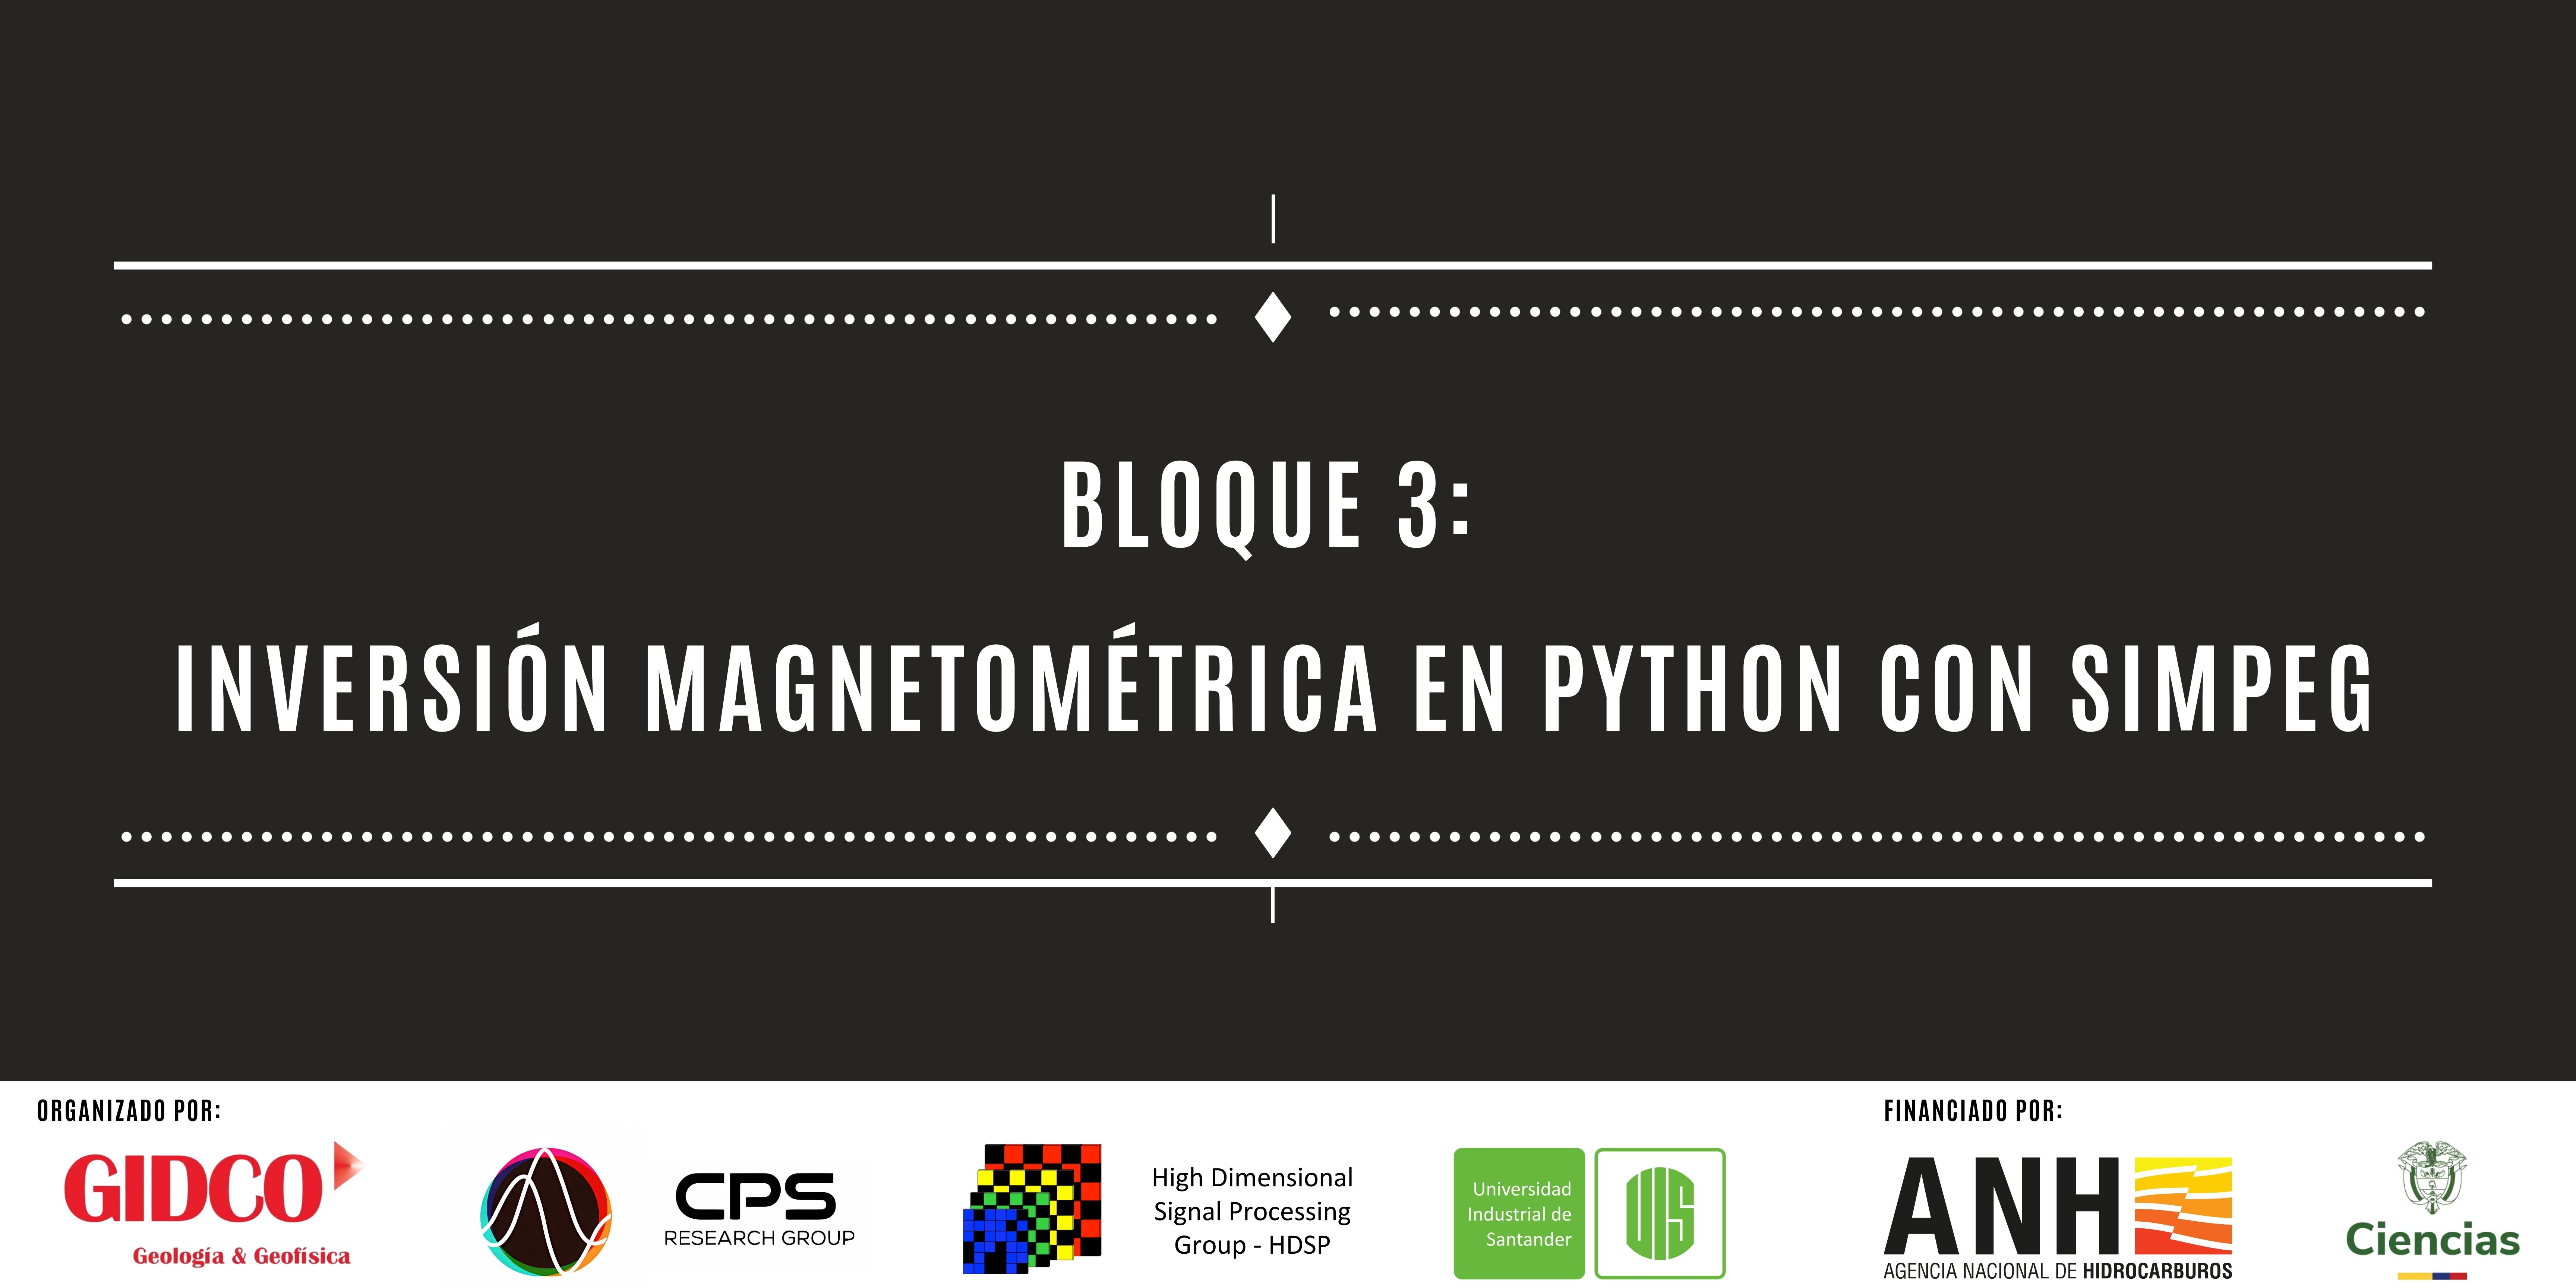

# 0. Inversión 3D de Magnetometría (TMI) con SimPEG — Caso real

En este notebook implementamos un flujo completo para invertir **datos reales de magnetometría** y recuperar un modelo 3D de **susceptibilidad magnética** del subsuelo.

**Objetivo principal:** estimar un modelo `m` (susceptibilidad, en **SI**) que reproduzca la anomalía observada de **Total Magnetic Intensity (TMI)** en las estaciones.

## Flujo de trabajo
1. Cargar **topografía** y datos de **TMI**.
2. Definir incertidumbre `sigma` y construir el *survey* magnetométrico.
3. Construir una malla 3D y seleccionar **celdas activas** bajo topografía.
4. Formular el problema inverso:
   $$
   \min_{\mathbf{m}}\; \phi_d(\mathbf{m}) + \beta\,\phi_m(\mathbf{m})
   $$
5. Ejecutar inversión y evaluar el ajuste (mapas + métricas).
6. Exportar el modelo a **VTI** para visualización 3D (ParaView).

## Unidades y convenciones
- Datos `dobs`: **nT** (TMI)
- Modelo `m`: **SI** (susceptibilidad)
- Residual `res`: $d_{obs}-d_{pred}$ en **nT**

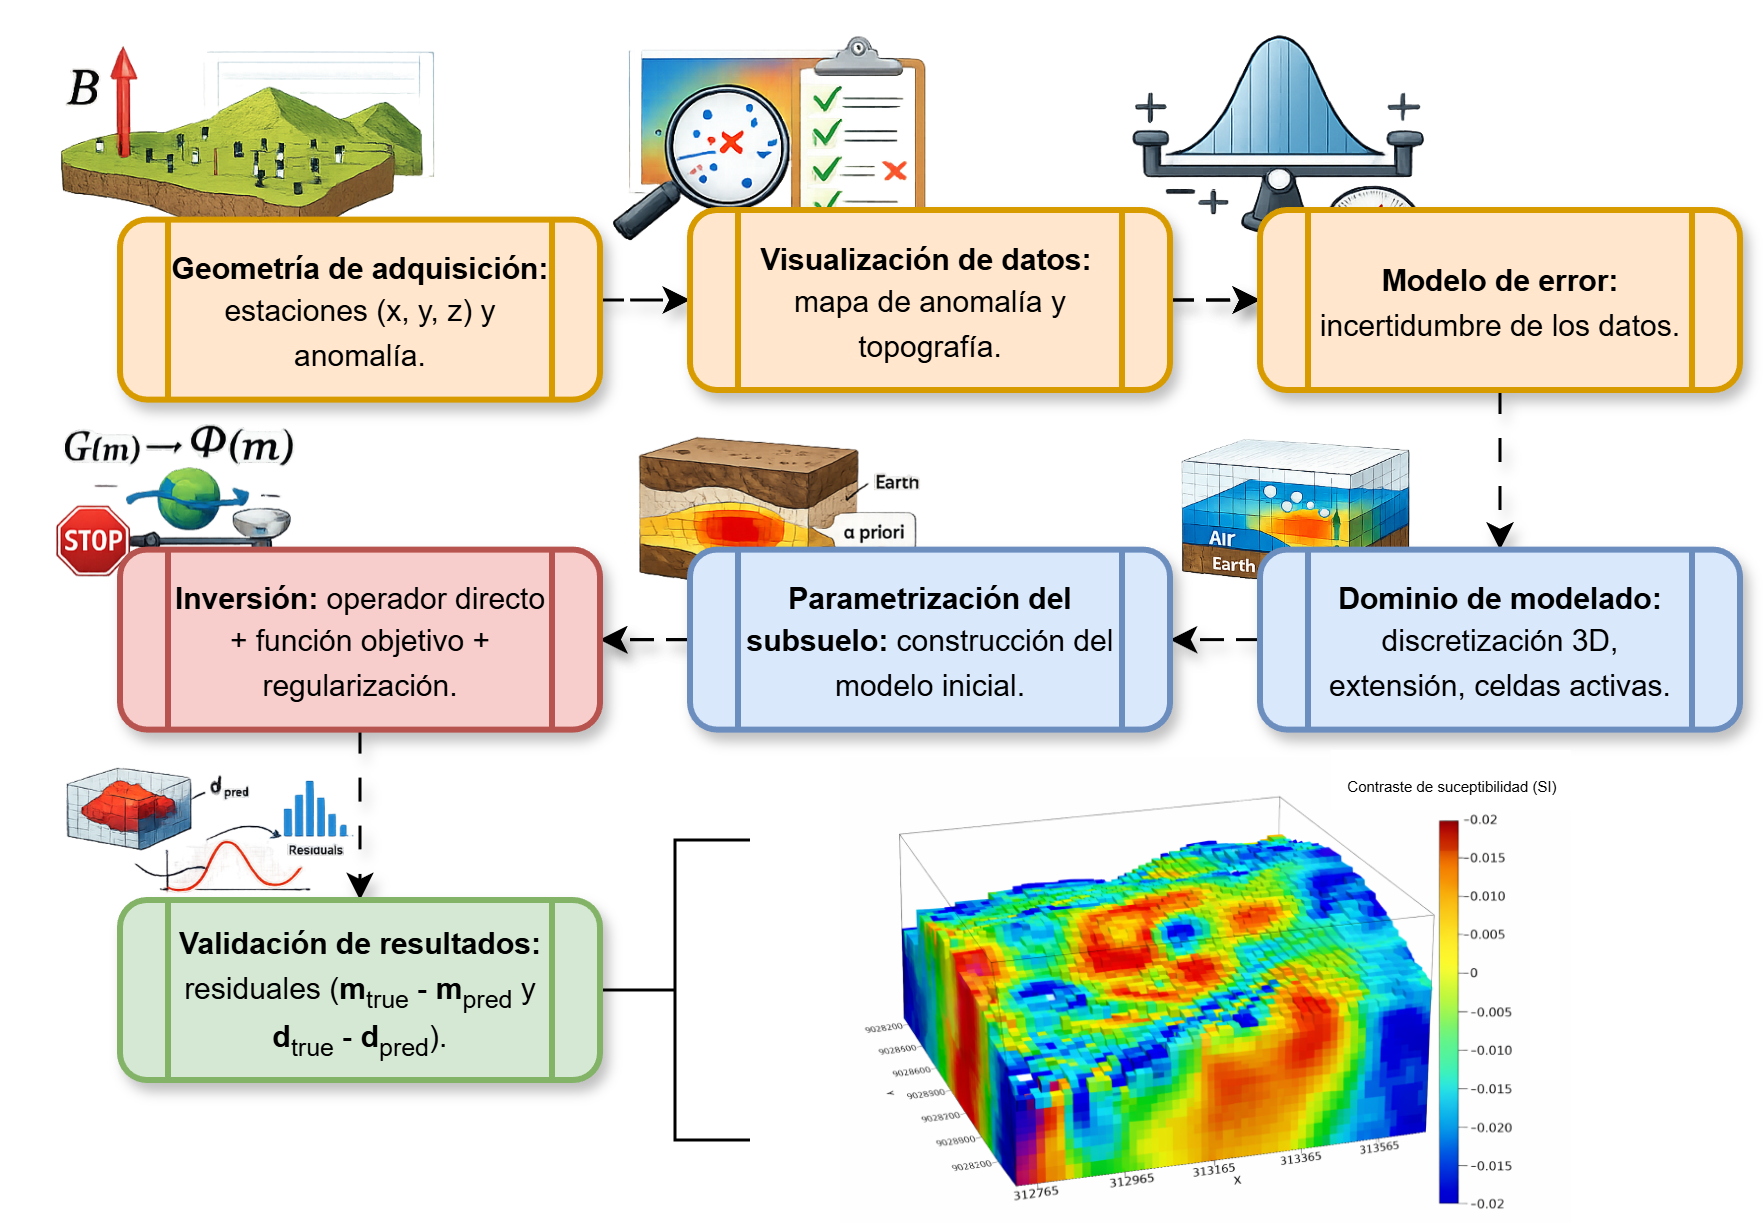

In [ ]:
!pip install simpeg
!pip -q install pyvista vtk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.9/513.9 kB 9.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.7/211.7 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 10.5 MB/s eta 0:00:00
  Created wheel for simpeg: filename=simpeg-0.25.2-py3-none-any.whl size=595275 sha256=b750b9e292167b114e1d4457ead7e3d7dbe4c941c05975eccdcc4257cca7470c
  Stored in directory: /root/.cache/pip/wheels/8a/db/6f/b6da5be3c64674bd3af27db599ff3f633a39e325b67485a2f1
  Created wheel for pymatsolver: filename=pymatsolver-0.4.0-py3-none-any.whl size=15857 sha256=fa57059ec6c70c3d2d26d99e54175b0d1cd4bc90b28370ab76030fed

# 1. Entorno e importación de librerías

En esta celda se reúnen los módulos necesarios para el flujo completo:

- `simpeg.potential_fields.magnetics`: física magnetométrica (TMI) y simulación integral 3D.
- `simpeg`: inversión (misfit, regularización, optimización, directivas).
- `discretize`: construcción de malla 3D y selección de `active_cells` bajo topografía.
- `matplotlib`: control de calidad (QC) y visualización 2D.
- `pyvista`: exportación del modelo 3D a formato `VTI`.

Además, se fijan parámetros gráficos para garantizar figuras legibles y consistentes en un entorno de presentación.


In [ ]:
# @title
# SimPEG functionality
from simpeg.potential_fields import magnetics
from simpeg.utils import plot2Ddata, model_builder, download
from simpeg import (
    maps,
    data,
    data_misfit,
    inverse_problem,
    regularization,
    optimization,
    directives,
    inversion,
    utils
)

# discretize functionality
from discretize import TensorMesh, TreeMesh
from discretize.utils import active_from_xyz
from discretize.utils import mkvc

# Common Python functionality
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import tarfile
import pyvista as pv
import pandas as pd

mpl.rcParams.update({"font.size": 14})


# 2. Carga de insumos: topografía y estaciones TMI

Se leen dos archivos fundamentales:

- `Topografia.txt`: puntos $(x,y,z)$ que describen la superficie.
- `Estaciones_AGCM_SGC_Magnetometria.txt`: estaciones $(x,y,z)$ y la anomalía observada `dobs`.

En esta etapa se separan explícitamente:
- `receiver_locations`: coordenadas de observación
- `dobs`: valores de TMI observados

Este paso asegura trazabilidad desde la fuente de datos hasta el objeto de inversión.


In [ ]:
TOPO_FILE = "Topografia.txt"  #@param {type:"string"}
DATA_FILE = "Estaciones_AGCM_SGC_Magnetometria.txt"  #@param {type:"string"}

xyz_topo = np.loadtxt(TOPO_FILE)
print("Topografía:", xyz_topo.shape)

dobs_all = np.loadtxt(DATA_FILE)
print("Datos MAG:", dobs_all.shape)

topografia = xyz_topo[:, 0:3]
receiver_locations = dobs_all[:, 0:3]
dobs = dobs_all[:, -1]

x = receiver_locations[:, 0]
y = receiver_locations[:, 1]
z = receiver_locations[:, 2]

Topografía: (32400, 3)
Datos MAG: (115, 4)


### Vista previa del formato (tablas)

In [ ]:
df_topo = pd.DataFrame(xyz_topo, columns=["x", "y", "z"])
df_obs  = pd.DataFrame(dobs_all, columns=["x", "y", "z", "dobs_nT"])

print("Topografía (primeras filas):")
display(df_topo.head(10))

print("Datos TMI (primeras filas):")
display(df_obs.head(10))

Topografía (primeras filas):


,x,y,z
0,4730206.409,2048780.271,1888.0
1,4730271.603,2048780.177,1855.0
2,4730336.796,2048780.082,1839.0
3,4730401.990,2048779.987,1834.0
4,4730467.184,2048779.892,1828.0
5,4730532.378,2048779.797,1810.0
6,4730597.572,2048779.702,1779.0
7,4730662.766,2048779.607,1763.0
8,4730727.959,2048779.512,1758.0
9,4730793.153,2048779.417,1753.0


Datos TMI (primeras filas):


,x,y,z,dobs_nT
0,4732886.295,2049348.167,1801.5,30.554386
1,4733090.108,2056498.079,1943.8,-31.919996
2,4733000.197,2056964.627,1985.3,2.217418
3,4732904.356,2057449.775,1990.2,-9.720388
4,4732885.709,2057951.810,2011.5,6.263119
5,4733023.464,2056314.276,1945.3,-12.376843
6,4732829.915,2056687.718,1946.7,18.550451
7,4732719.664,2057144.713,1987.1,9.132828
8,4732728.136,2057658.602,2009.1,-19.229490
9,4732612.780,2056338.857,2188.3,-20.471672


# 3. Control de calidad visual (QC): datos y topografía

Antes de invertir, se realiza un control de calidad para verificar:

- Cobertura espacial de las estaciones `receiver_locations`.
- Patrón y amplitud de la anomalía `dobs` (identificación de tendencias, vacíos y posibles outliers).
- Coherencia espacial entre el dominio de datos y el dominio topográfico.

Se grafican dos mapas 2D con barras de color independientes:
1) Anomalía TMI observada (`dobs`)
2) Elevación topográfica (`xyz_topo`)

Este QC reduce el riesgo de invertir datos con errores de formato, coordenadas inconsistentes o cobertura incompleta.


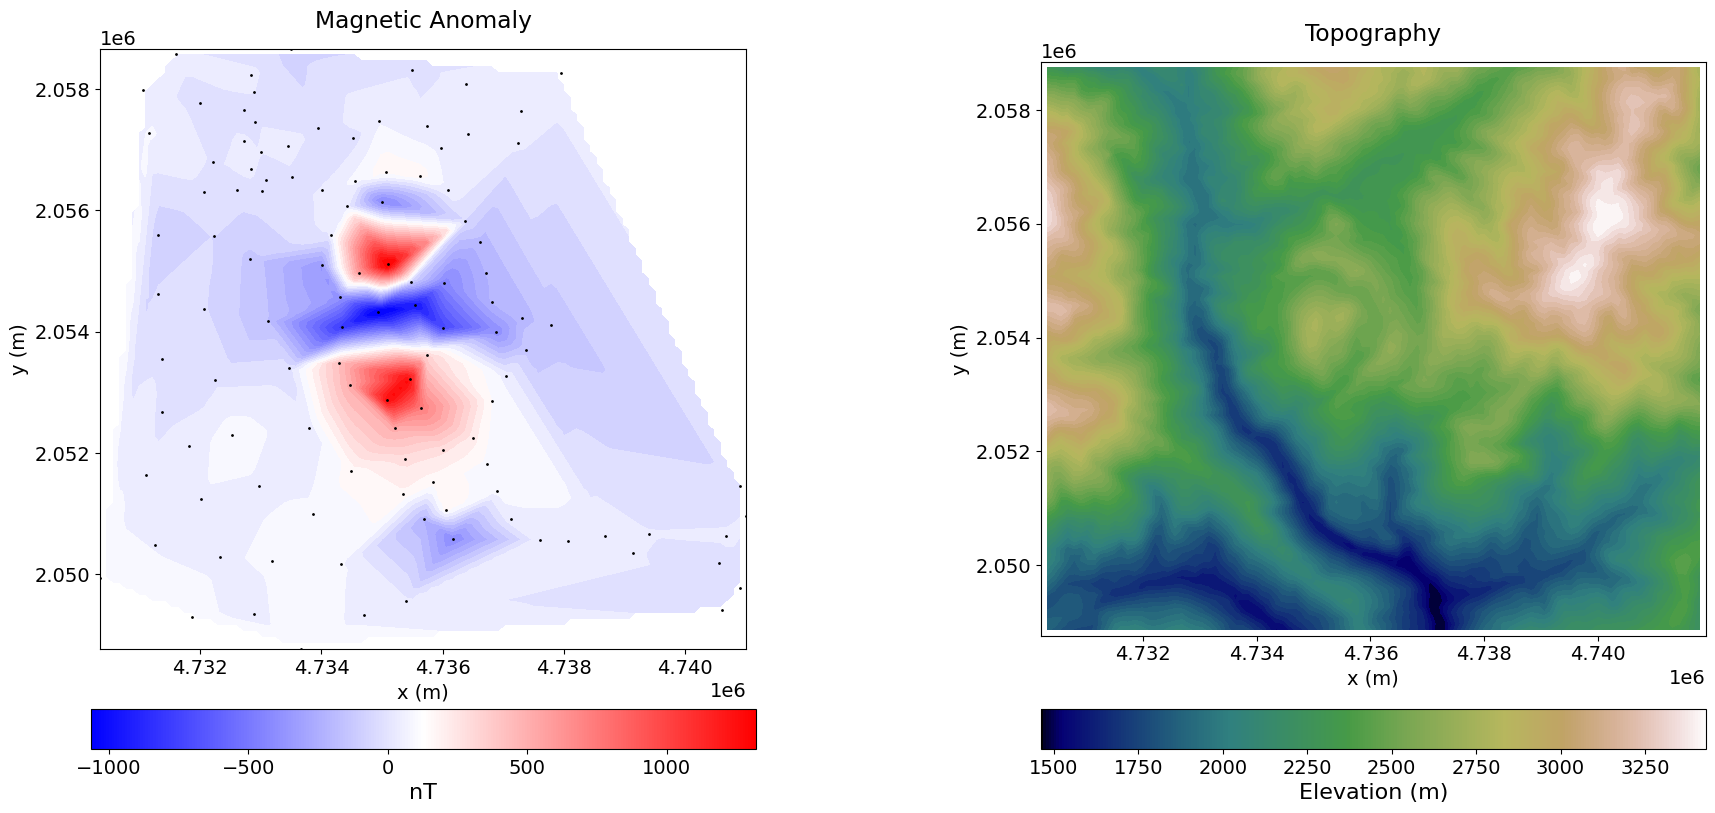

In [ ]:
NCONTOUR_DATA = 40  #@param {type:"integer", min:5, max:200, step:5}
NCONTOUR_TOPO = 50  #@param {type:"integer", min:5, max:200, step:5}

fig = plt.figure(figsize=(19, 10))

# --- 1) TMI ---
ax1 = fig.add_axes([0.05, 0.35, 0.35, 0.6])
plot2Ddata(
    receiver_locations,
    dobs,
    ax=ax1,
    dataloc=True,
    ncontour=NCONTOUR_DATA,
    contourOpts={"cmap": "bwr"},
)
ax1.set_title("Magnetic Anomaly", pad=15)
ax1.set_xlabel("x (m)")
ax1.set_ylabel("y (m)")

cx1 = fig.add_axes([0.05, 0.25, 0.35, 0.04])
norm1 = mpl.colors.Normalize(vmin=np.min(dobs), vmax=np.max(dobs))
cbar1 = mpl.colorbar.ColorbarBase(cx1, norm=norm1, orientation="horizontal", cmap=mpl.cm.bwr)
cbar1.set_label("nT", size=16)

# --- 2) Topografía ---
ax2 = fig.add_axes([0.55, 0.35, 0.35, 0.6])
plot2Ddata(
    xyz_topo[:, 0:2],
    xyz_topo[:, -1],
    ax=ax2,
    dataloc=False,
    ncontour=NCONTOUR_TOPO,
    contourOpts={"cmap": "gist_earth"},
)
ax2.set_title("Topography", pad=15)
ax2.set_xlabel("x (m)")
ax2.set_ylabel("y (m)")

cx2 = fig.add_axes([0.55, 0.25, 0.35, 0.04])
norm2 = mpl.colors.Normalize(vmin=np.min(xyz_topo[:, -1]), vmax=np.max(xyz_topo[:, -1]))
cbar2 = mpl.colorbar.ColorbarBase(cx2, norm=norm2, orientation="horizontal", cmap=mpl.cm.gist_earth)
cbar2.set_label("Elevation (m)", size=16)

plt.show()

## 4. Modelo de incertidumbre `sigma` (notación tipo GIFtools)

Misfit ponderado:
$$
\phi_d(\mathbf{m})=
\sum_{i=1}^{N}\left(\frac{F(\mathbf{m})_i-d_i}{\varepsilon_i}\right)^2
=
\left\|\mathbf{W}_d\left(\mathbf{d}-\mathbf{F}(\mathbf{m})\right)\right\|_2^2,
\qquad
\mathbf{W}_d=\mathrm{diag}(\varepsilon_i^{-1})
$$

Modelo mixto típico:
$$
\varepsilon_i=\varepsilon_{\text{floor}}+C_\%|d_i|
$$

In [ ]:
rel_unc = 0.02    #@param {type:"number", min:0, max:0.5, step:0.005}
floor_unc = 0.05  #@param {type:"number", min:0, max:50.0, step:0.01}

sigma = floor_unc + rel_unc * np.abs(dobs)

print(
    f"Unc stats -> floor={floor_unc:.3f} nT, rel={100*rel_unc:.1f}%, "
    f"median σ={np.median(sigma):.3f} nT"
)

Unc stats -> floor=0.050 nT, rel=2.0%, median σ=1.028 nT


# 5. Definición del survey magnetométrico y objeto `Data`

Se define el experimento magnetométrico mediante:

- Componente invertida: `components = ["tmi"]`
- Receptores: `magnetics.receivers.Point(receiver_locations, components=...)`
- Campo inducido regional (suposición estándar en inversión de TMI):
  - `inclination`, `declination`, `amplitude`

Con estos elementos se crea el `survey` y el objeto `data_object`, que integra:
- datos observados `dobs`,
- incertidumbres `sigma`,
- geometría y parámetros físicos del problema.

Este paso formaliza el enlace entre observaciones y el modelo directo/inverso.

In [ ]:
components = ["tmi"]

inclination = 26.4397  #@param {type:"number", min:-90, max:90, step:0.1}
declination = -8.6336  #@param {type:"number", min:-180, max:180, step:0.1}
amplitude = 29968.4    #@param {type:"number", min:0, max:200000, step:10}

receiver_obj = magnetics.receivers.Point(receiver_locations, components=components)
source_field = magnetics.sources.UniformBackgroundField(
    receiver_list=[receiver_obj],
    amplitude=amplitude,
    inclination=inclination,
    declination=declination,
)

survey = magnetics.survey.Survey(source_field)
data_object = data.Data(survey, dobs=dobs, standard_deviation=sigma)

print("Survey/Data listos.")

Survey/Data listos.


# 6. Malla 3D: discretización del subsuelo

La inversión requiere un dominio discretizado donde se estima la susceptibilidad `m`.
Se define una `TensorMesh` con:

- `dx, dy, dz`: tamaño de celda
- `ncx, ncy, ncz`: número de celdas por eje
- `x0`: origen de la malla (esquina inferior) en coordenadas reales

La malla determina:
- la resolución espacial recuperable,
- el costo computacional,
- y el soporte geométrico del modelo final.


In [ ]:
dx = 260  #@param {type:"number", min:1, max:5000, step:1}
dy = 275  #@param {type:"number", min:1, max:5000, step:1}
dz = 225  #@param {type:"number", min:1, max:5000, step:1}

ncx = 50  #@param {type:"integer", min:1, max:500, step:1}
ncy = 40  #@param {type:"integer", min:1, max:500, step:1}
ncz = 45  #@param {type:"integer", min:1, max:500, step:1}

x0_x = 4729500  #@param {type:"number"}
x0_y = 2048000  #@param {type:"number"}
x0_z = -6000    #@param {type:"number"}

hx = [(dx, ncx)]
hy = [(dy, ncy)]
hz = [(dz, ncz)]

mesh = TensorMesh([hx, hy, hz], x0=[x0_x, x0_y, x0_z])

print("Mesh shape cells:", mesh.shape_cells)
print("nC total:", mesh.nC)

Mesh shape cells: (50, 40, 45)
nC total: 90000


# 7. QC de malla: cobertura de estaciones y geometría


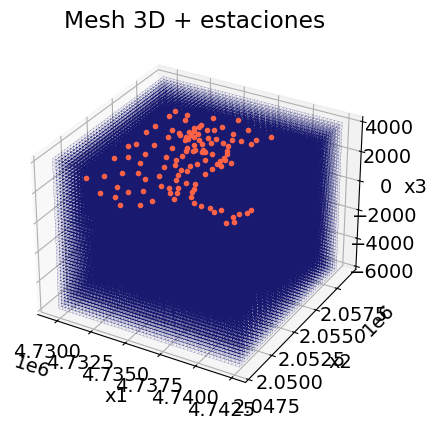

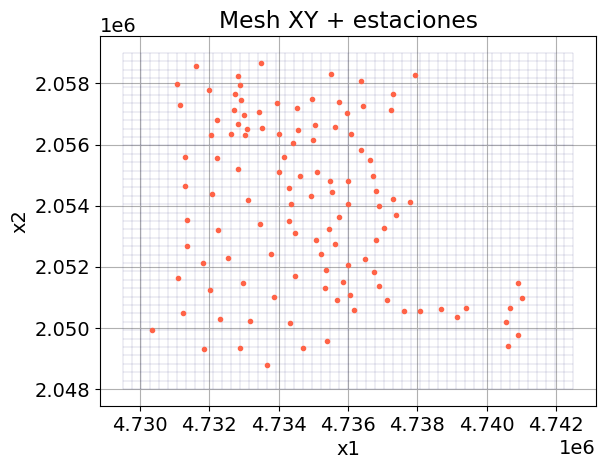

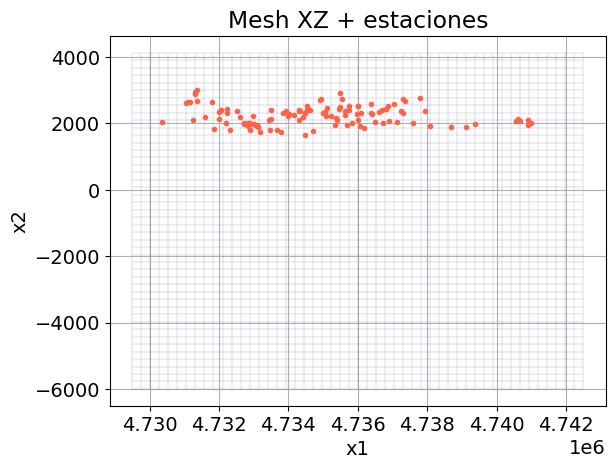

In [ ]:
# @title
mesh.plot_grid(color="midnightblue", linewidth=0.1)
plt.plot(x, y, z, ".", color="tomato")
plt.title("Mesh 3D + estaciones")
plt.show()

meshes_xy = TensorMesh([hx, hy], x0=[x0_x, x0_y])
meshes_xy.plot_grid(color="midnightblue", linewidth=0.1)
plt.plot(x, y, ".", color="tomato")
plt.title("Mesh XY + estaciones")
plt.show()

meshes_xz = TensorMesh([hx, hz], x0=[x0_x, x0_z])
meshes_xz.plot_grid(color="midnightblue", linewidth=0.1)
plt.plot(x, z, ".", color="tomato")
plt.title("Mesh XZ + estaciones")
plt.show()

# 8. Celdas activas, mapeos y modelo inicial

Se definen:

- Modelo inicial `starting_tensor_model`: pequeño y no nulo (evita gradiente cero al inicio).
- Modelo de referencia `reference_tensor_model`: típicamente cero si no hay información a-priori.
- Mapa de ploteo `tensor_plotting_map`: inserta `NaN` en celdas inactivas para visualizar cortes sin “aire”.


In [ ]:
active_tensor_cells = active_from_xyz(mesh, topografia)
n_tensor_active = int(active_tensor_cells.sum())
print("Active cells:", n_tensor_active)

tensor_model_map = maps.IdentityMap(nP=n_tensor_active)

STARTING_VALUE = 1e-6  #@param {type:"number"}
starting_tensor_model = STARTING_VALUE * np.ones(n_tensor_active)

reference_tensor_model = np.zeros_like(starting_tensor_model)
tensor_plotting_map = maps.InjectActiveCells(mesh, active_tensor_cells, np.nan)

Active cells: 74727


### Corte 2D: topografía + malla + activas/inactivas (qué se invierte y qué no)

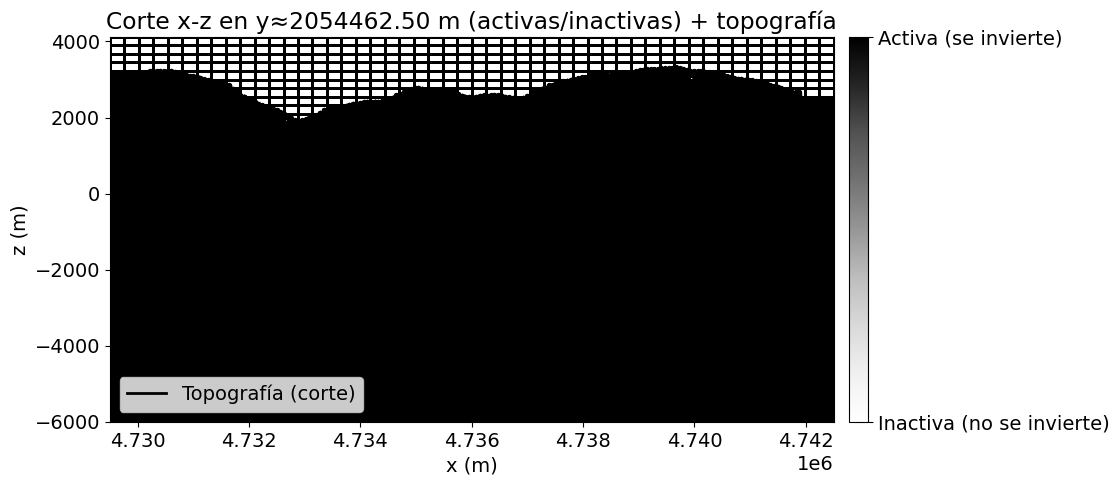

In [ ]:
SLICE_Y_LOC = 2054372  #@param {type:"number"}

y_centers = mesh.cell_centers[:, 1]
y0 = y_centers[np.argmin(np.abs(y_centers - SLICE_Y_LOC))]

active_full = np.zeros(mesh.nC)
active_full[active_tensor_cells] = 1.0

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

out = mesh.plot_slice(
    active_full,
    normal="Y",
    slice_loc=y0,
    ax=ax,
    grid=True,
    pcolor_opts={"cmap": "Greys", "vmin": 0, "vmax": 1},
)
cbar = plt.colorbar(out[0], ax=ax, fraction=0.046, pad=0.02)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["Inactiva (no se invierte)", "Activa (se invierte)"])

tol = max(mesh.h[1].min(), 5.0)
mask_topo = np.abs(topografia[:, 1] - y0) < tol
topo_cut = topografia[mask_topo]

if topo_cut.shape[0] > 5:
    topo_cut = topo_cut[np.argsort(topo_cut[:, 0])]
    ax.plot(topo_cut[:, 0], topo_cut[:, 2], "k-", lw=2, label="Topografía (corte)")
    ax.scatter(topo_cut[:, 0], topo_cut[:, 2], s=8, c="k")
    ax.legend(loc="lower left")
else:
    ax.text(
        0.02, 0.95,
        "Pocos puntos de topografía en este corte.\nPrueba otro SLICE_Y_LOC.",
        transform=ax.transAxes, va="top"
    )

ax.set_title(f"Corte x-z en y≈{y0:.2f} m (activas/inactivas) + topografía")
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
plt.show()

# 9. Verificación rápida del modelo inicial (slice)

Se inspecciona un corte 2D del modelo inicial para confirmar:

- correcta aplicación de celdas activas,
- consistencia espacial con topografía y dominio,
- ausencia de escalas absurdas en el punto de partida.

Este chequeo es un paso simple pero altamente efectivo para evitar ejecutar una inversión completa sobre una discretización incorrecta.


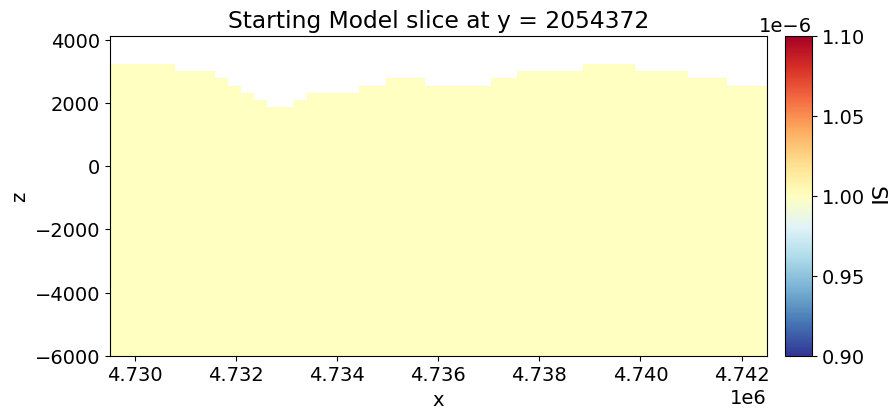

In [ ]:
slice_loc = 2054372  #@param {type:"number"}
slice_normal = "y"   #@param ["x","y","z"]

fig = plt.figure(figsize=(9, 4))
ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.8])

norm = mpl.colors.Normalize(vmin=np.min(starting_tensor_model), vmax=np.max(starting_tensor_model))

mesh.plot_slice(
    tensor_plotting_map * starting_tensor_model,
    normal=slice_normal,
    ax=ax1,
    slice_loc=slice_loc,
    grid=False,
    pcolor_opts={"cmap": mpl.cm.RdYlBu_r, "norm": norm},
)
ax1.set_title(f"Starting Model slice at {slice_normal} = {slice_loc}")

ax2 = fig.add_axes([0.85, 0.1, 0.03, 0.8])
cbar = mpl.colorbar.ColorbarBase(ax2, norm=norm, orientation="vertical", cmap=mpl.cm.RdYlBu_r)
cbar.set_label("SI", rotation=270, labelpad=15, size=16)

plt.show()

## 10. Operador directo (TMI inducido) + forward y misfit

Magnetización inducida (modelo escalar):
$$
\mathbf{M}(\mathbf{r})=\kappa(\mathbf{r})\,\mathbf{H}_0
$$

Campo inducido (operador lineal en $\kappa$:
$$
\Delta \mathbf{B}(\mathbf{r}_i)=
\mu_0 \int_V \mathbf{K}(\mathbf{r}_i,\mathbf{r}')\,\mathbf{M}(\mathbf{r}')\,dV'
$$

TMI (aprox. proyección sobre $\mathbf{B}_0$):
$$
d_i \approx \hat{\mathbf{b}}_0^{\mathsf{T}}\Delta \mathbf{B}(\mathbf{r}_i)
\quad\Rightarrow\quad
\mathbf{d}=\mathbf{G}\mathbf{m}
$$

In [ ]:
simulation_irls = magnetics.simulation.Simulation3DIntegral(
    survey=survey,
    mesh=mesh,
    model_type="scalar",
    chiMap=tensor_model_map,
    active_cells=active_tensor_cells
)

dmis_irls = data_misfit.L2DataMisfit(data=data_object, simulation=simulation_irls)
print("Forward + misfit listos.")

Forward + misfit listos.


# 11. Pesos físicos/geométricos: profundidad y distancia

En potenciales es común incorporar pesos para estabilizar y guiar la inversión.

- `wr_Depth` (depth weighting): compensa la disminución natural de sensibilidad con profundidad.
- `distance_Weights` (distance weighting): penaliza gradientes de acuerdo a cercanía/estructura espacial alrededor de las estaciones.

Estos pesos buscan mejorar la interpretabilidad del modelo evitando soluciones dominadas por la cercanía superficial o por geometrías numéricamente convenientes pero físicamente poco realistas.


In [ ]:
DEPTH_V = 5   #@param {type:"number", min:0, max:1e6, step:1}
DEPTH_Z0 = 5  #@param {type:"number", min:0, max:1e6, step:1}

DIST_EXPONENT = 3  #@param {type:"integer", min:0, max:6, step:1}

wr_Depth = utils.depth_weighting(
    mesh, receiver_locations, active_cells=active_tensor_cells, v=DEPTH_V, z0=DEPTH_Z0
)

distance_Weights = utils.distance_weighting(
    mesh, receiver_locations, active_cells=active_tensor_cells, exponent=DIST_EXPONENT
)

print("Pesos listos: depth + distance.")

Pesos listos: depth + distance.


# 12. Regularización Sparse (IRLS): control de complejidad y “blockiness”

El problema inverso es no único, por lo que se incorpora regularización:

$$
J(\mathbf{m})=\phi_d(\mathbf{m})+\beta\,\phi_m(\mathbf{m})
$$

En esta inversión se usa `regularization.Sparse` con un esquema tipo IRLS para promover modelos más **compactos / blocky** en comparación con una WLS puramente suave.

Se define:
- escalamiento (`alpha_s`, `alpha_x`, `alpha_y`, `alpha_z`)
- normas `norms=[2,1,1,1]` (combinación de smallness y suavidad tipo $L_1$ en gradientes)
- pesos `cell_weights` y `gradients_weights`

Este bloque controla el balance entre:
- ajuste a datos,
- estabilidad,
- y el tipo de geometría recuperada.


In [ ]:
alpha_s = 1.0  #@param {type:"number"}
alpha_x = 1.0  #@param {type:"number"}
alpha_y = 1.0  #@param {type:"number"}
alpha_z = 1.0  #@param {type:"number"}

norm_small = 2  #@param {type:"integer", min:0, max:2, step:1}
norm_grad = 1   #@param {type:"integer", min:0, max:2, step:1}

reg_irls = regularization.Sparse(
    mesh,
    active_cells=active_tensor_cells,
    alpha_s=alpha_s,
    alpha_x=alpha_x,
    alpha_y=alpha_y,
    alpha_z=alpha_z,
    reference_model=reference_tensor_model,
    reference_model_in_smooth=True,
    norms=[norm_small, norm_grad, norm_grad, norm_grad],
    weights={
        "cell_weights": wr_Depth,
        "gradients_weights": distance_Weights
    }
)

print("Regularización Sparse lista.")

Regularización Sparse lista.


# 13. Optimización y definición del problema inverso

Se define cómo se resuelve numéricamente:

- `ProjectedGNCG`: Gauss-Newton proyectado + CG
- límites `lower` / `upper` para restringir la susceptibilidad recuperada dentro de rangos físicamente plausibles.

Luego se construye el problema inverso:
- `inv_prob = BaseInvProblem(dmis, reg, opt)`

Aquí queda completamente definido el “motor” del problema: misfit + regularización + método de minimización.


In [ ]:
maxIter = 100   #@param {type:"integer", min:1, max:500, step:1}
lower = -0.1    #@param {type:"number"}
upper = 0.1     #@param {type:"number"}

maxIterLS = 80  #@param {type:"integer", min:1, max:500, step:1}
maxIterCG = 50  #@param {type:"integer", min:1, max:1000, step:1}
tolCG = 1e-2    #@param {type:"number"}

opt_irls = optimization.ProjectedGNCG(
    maxIter=maxIter, lower=lower, upper=upper,
    maxIterLS=maxIterLS, maxIterCG=maxIterCG, tolCG=tolCG
)

inv_prob_irls = inverse_problem.BaseInvProblem(dmis_irls, reg_irls, opt_irls)

/usr/local/lib/python3.12/dist-packages/simpeg/optimization.py:1535: FutureWarning: InexactCG.tolCG has been deprecated, please use InexactCG.cg_atol. It will be removed in version 0.26.0 of SimPEG.
  self.tolCG = val
/usr/local/lib/python3.12/dist-packages/simpeg/optimization.py:1061: FutureWarning: InexactCG.maxIterCG has been deprecated, please use InexactCG.cg_maxiter. It will be removed in version 0.26.0 of SimPEG.
  self.maxIterCG = val


# 14. Directivas IRLS y ejecución de la inversión

Las `directives` automatizan operaciones clave durante la inversión:

- `UpdateIRLS`: controla ciclos IRLS y enfriamiento de $\beta$ durante la estrategia sparse.
- `UpdateSensitivityWeights`: aplica pesos por sensibilidad para mitigar concentración cerca de estaciones.
- `BetaEstimate_ByEig`: estima $\beta_0$ inicial a partir de información espectral.
- `UpdatePreconditioner`: mejora convergencia del solver.
- `TargetMisfit`: detiene cuando el misfit es consistente con el nivel de ruido asumido.
- `SaveOutputDictEveryIteration`: guarda historial para trazabilidad y auditoría.

Finalmente se ejecuta:
- `recovered_model = inv.run(starting_tensor_model)`

Este es el paso donde se obtiene el modelo 3D de susceptibilidad.


In [ ]:
SENS_THRESH = 1e-10  #@param {type:"number"}
BETA0_RATIO = 1.0    #@param {type:"number", min:1e-3, max:100, step:0.1}

IRLS_COOL_RATE = 2.0     #@param {type:"number", min:1.0, max:10.0, step:0.1}
IRLS_COOL_FACTOR = 2.0   #@param {type:"number", min:1.0, max:10.0, step:0.1}
IRLS_CHIFACT_START = 1.0 #@param {type:"number", min:0.1, max:10.0, step:0.1}
IRLS_FMIN = 1e-4         #@param {type:"number"}
IRLS_MAX = 30            #@param {type:"integer", min:1, max:200, step:1}

TARGET_CHIFACT = 1.0     #@param {type:"number", min:0.1, max:10.0, step:0.1}

save_iteration_new = directives.SaveOutputDictEveryIteration()
save_iteration_new.outDict = {}

sensitivity_weights_irls = directives.UpdateSensitivityWeights(
    every_iteration=True,
    threshold_value=SENS_THRESH,
    threshold_method="amplitude",
    normalization_method="maximum",
)

starting_beta_irls = directives.BetaEstimate_ByEig(beta0_ratio=BETA0_RATIO)
update_jacobi_irls = directives.UpdatePreconditioner(update_every_iteration=True)

update_irls = directives.UpdateIRLS(
    cooling_rate=IRLS_COOL_RATE,
    cooling_factor=IRLS_COOL_FACTOR,
    chifact_start=IRLS_CHIFACT_START,
    f_min_change=IRLS_FMIN,
    max_irls_iterations=IRLS_MAX
)

tarjet_misfit = directives.TargetMisfit(chifact=TARGET_CHIFACT)

directives_list_irls = [
    update_irls,
    sensitivity_weights_irls,
    starting_beta_irls,
    update_jacobi_irls,
    tarjet_misfit,
    save_iteration_new
]

In [ ]:
inv_irls = inversion.BaseInversion(inv_prob_irls, directives_list_irls)
recovered_model = inv_irls.run(starting_tensor_model)


Running inversion with SimPEG v0.25.2


INFO: Directive TargetMisfit: Target data misfit is 115.0
INFO:SimPEG:Directive TargetMisfit: Target data misfit is 115.0


================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  5.13e+03  2.45e+05  6.09e-05  2.45e+05                         0           inf          inf                
   1  5.13e+03  6.15e+04  3.51e+00  7.95e+04    2.86e+01      0      50       4.82e-02     8.92e+05              
   2  5.13e+03  4.43e+04  3.69e+00  6.33e+04    2.99e+01      0      50       6.64e-03     8.13e+04              
   3  2.57e+03  3.93e+04  5.09e+00  5.24e+04    2.97e+01      1      50       1.07e-01     2.12e+05              
   4  2.57e+03  3.30e+04  6.84e+00  5.06e+04    2.96e+01      0      50       3.18e-02     1.30e+05              
   5  1.28e+03  3.08e+04  7.97e+00  4.11e+04    2.99e+01      2      50       1.57e-01 

# 15. Inspección del modelo recuperado (cortes 2D)

Se visualiza el modelo final `recovered_model` mediante cortes:

- `normal="y"`: sección longitudinal/transversal en coordenada real.
- `normal="x"`: sección alternativa para evaluar continuidad y geometría.

Estas figuras permiten una primera lectura geológica/geofísica:
- localización de cuerpos magnéticos,
- continuidad espacial,
- amplitudes relativas,
- posibles efectos de borde.

En un reporte técnico, estos cortes son el “producto interpretativo” más inmediato del modelo invertido.


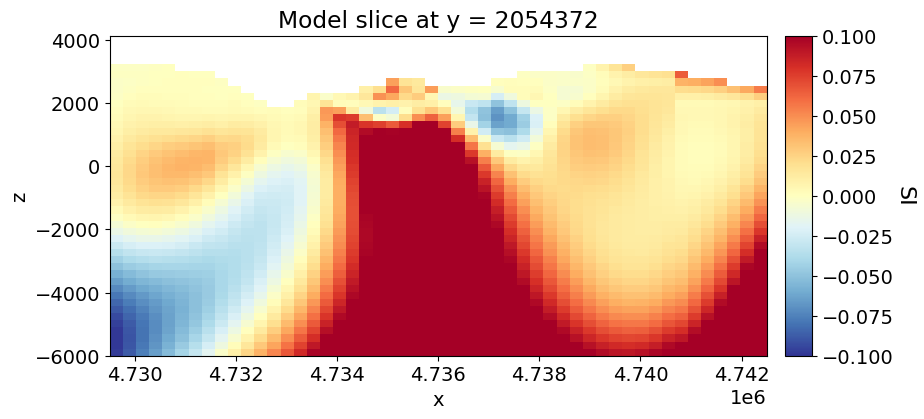

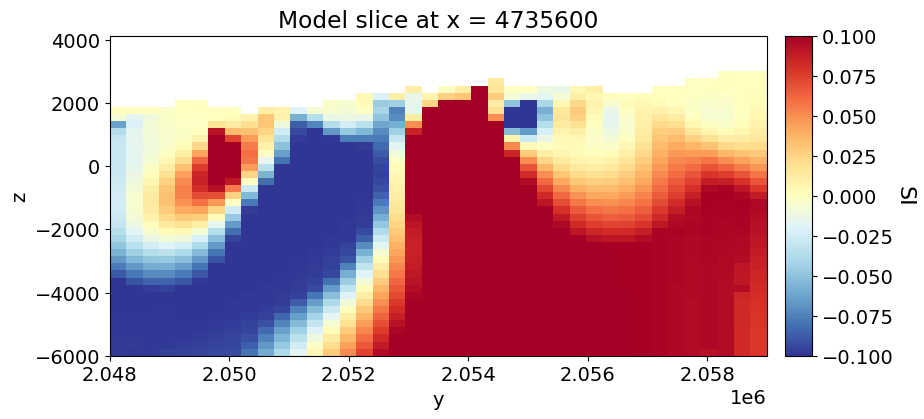

In [ ]:
# Slice en Y
slice_loc_y = 2054372  #@param {type:"number"}
fig = plt.figure(figsize=(9, 4))
ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.8])

norm = mpl.colors.Normalize(vmin=np.min(recovered_model), vmax=np.max(recovered_model))
mesh.plot_slice(
    tensor_plotting_map * recovered_model,
    normal="y",
    ax=ax1,
    slice_loc=slice_loc_y,
    grid=False,
    pcolor_opts={"cmap": mpl.cm.RdYlBu_r, "norm": norm},
)
ax1.set_title(f"Model slice at y = {slice_loc_y}")

ax2 = fig.add_axes([0.85, 0.1, 0.03, 0.8])
cbar = mpl.colorbar.ColorbarBase(ax2, norm=norm, orientation="vertical", cmap=mpl.cm.RdYlBu_r)
cbar.set_label("SI", rotation=270, labelpad=15, size=16)
plt.show()

# Slice en X
slice_loc_x = 4735600  #@param {type:"number"}
fig = plt.figure(figsize=(9, 4))
ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.8])

norm = mpl.colors.Normalize(vmin=np.min(recovered_model), vmax=np.max(recovered_model))
mesh.plot_slice(
    tensor_plotting_map * recovered_model,
    normal="x",
    ax=ax1,
    slice_loc=slice_loc_x,
    grid=False,
    pcolor_opts={"cmap": mpl.cm.RdYlBu_r, "norm": norm},
)
ax1.set_title(f"Model slice at x = {slice_loc_x}")

ax2 = fig.add_axes([0.85, 0.1, 0.03, 0.8])
cbar = mpl.colorbar.ColorbarBase(ax2, norm=norm, orientation="vertical", cmap=mpl.cm.RdYlBu_r)
cbar.set_label("SI", rotation=270, labelpad=15, size=16)
plt.show()

# 16. Ajuste en el espacio de datos: observado vs predicho vs residual

Una solución no se evalúa solo por el modelo; debe reproducir los datos.

Se calculan:
- `dpred`: datos predichos por el modelo final
- `res = dobs - dpred`: residual

Se grafican mapas:
1) `dpred`
2) `dobs`
3) `res`

Criterios recomendados:
- Observado y predicho con la misma escala (comparación directa).
- Residual con escala simétrica $\pm \max(|res|)$ para identificar patrones sistemáticos.

Un residual con estructura espacial puede indicar:
- necesidad de recalibrar `sigma`,
- necesidad de enriquecer la parametrización (p.ej. remanencia),
- o limitaciones de malla/regularización.


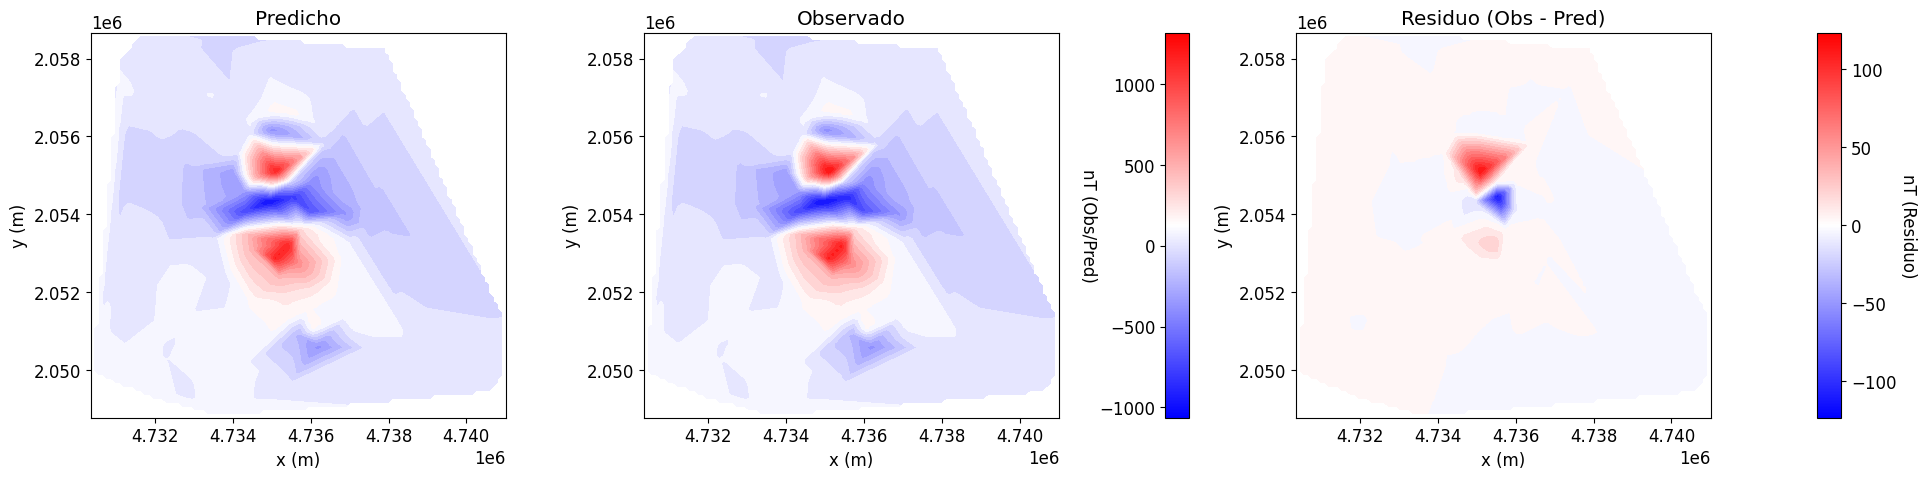

In [ ]:
dpred = inv_prob_irls.dpred
res = dobs - dpred

vmin = np.nanmin([np.nanmin(dpred), np.nanmin(dobs)])
vmax = np.nanmax([np.nanmax(dpred), np.nanmax(dobs)])
clim = [vmin, vmax]

rmax = np.nanmax(np.abs(res))
rclim = [-rmax, rmax]

mpl.rcParams.update({"font.size": 12})

fig = plt.figure(figsize=(23, 5))
gs = fig.add_gridspec(1, 5, width_ratios=[1, 1, 0.05, 1, 0.05], wspace=0.25)

ax_pred  = fig.add_subplot(gs[0, 0])
ax_obs   = fig.add_subplot(gs[0, 1])
cax_main = fig.add_subplot(gs[0, 2])
ax_res   = fig.add_subplot(gs[0, 3])
cax_res  = fig.add_subplot(gs[0, 4])

plot2Ddata(receiver_locations, dpred, ax=ax_pred, ncontour=30, clim=clim, contourOpts={"cmap": "bwr"})
ax_pred.set_title("Predicho")
ax_pred.set_xlabel("x (m)")
ax_pred.set_ylabel("y (m)")

plot2Ddata(receiver_locations, dobs, ax=ax_obs, ncontour=30, clim=clim, contourOpts={"cmap": "bwr"})
ax_obs.set_title("Observado")
ax_obs.set_xlabel("x (m)")
ax_obs.set_ylabel("y (m)")

plot2Ddata(receiver_locations, res, ax=ax_res, ncontour=30, clim=rclim, contourOpts={"cmap": "bwr"})
ax_res.set_title("Residuo (Obs - Pred)")
ax_res.set_xlabel("x (m)")
ax_res.set_ylabel("y (m)")

norm1 = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cb1 = mpl.colorbar.ColorbarBase(cax_main, norm=norm1, orientation="vertical", cmap=mpl.cm.bwr)
cb1.set_label("nT (Obs/Pred)", rotation=270, labelpad=15, size=12)
cax_main.yaxis.set_ticks_position("left")
cax_main.yaxis.set_label_position("left")

norm2 = mpl.colors.Normalize(vmin=rclim[0], vmax=rclim[1])
cb2 = mpl.colorbar.ColorbarBase(cax_res, norm=norm2, orientation="vertical", cmap=mpl.cm.bwr)
cb2.set_label("nT (Residuo)", rotation=270, labelpad=15, size=12)
cax_res.yaxis.set_ticks_position("right")
cax_res.yaxis.set_label_position("right")

plt.show()

# 17. Métricas cuantitativas de ajuste

Además de los mapas, se reportan métricas para sustentar el desempeño:

Sea `r = dobs - dpred` y $N$ el número de datos:

- $RMSE=\sqrt{\frac{1}{N}\sum r_i^2}$
- $MAE=\frac{1}{N}\sum |r_i|$
- $\chi^2_{red}=\frac{\phi_d}{N}$ (misfit reportado por SimPEG)

Interpretación:
- Si $\chi^2_{red}\approx 1$, el ajuste es consistente con el nivel de ruido asumido en `sigma`.
- Si $\chi^2_{red}\gg 1$, el modelo no explica el dato dentro del ruido (o `sigma` es optimista).
- Si $\chi^2_{red}\ll 1$, `sigma` puede ser demasiado conservadora o hay sobreajuste.

Estas métricas facilitan comparaciones objetivas entre configuraciones (malla, regularización, pesos).


In [ ]:
dpred = inv_prob_irls.dpred
res   = dobs - dpred
N     = res.size

rmse = np.sqrt(np.mean(res**2))
mae  = np.mean(np.abs(res))
rmse_w = np.sqrt(np.mean((res / sigma)**2))

phi_d = inv_prob_irls.dmisfit(recovered_model)
chi2_red = phi_d / N

print("\n===== MÉTRICAS DE AJUSTE =====")
print(f"RMSE              : {rmse:.4f} mGal")   # (nota: etiqueta heredada)
print(f"MAE               : {mae:.4f} mGal")
print(f"Chi^2             : {chi2_red:.4f}")
print("================================")


===== MÉTRICAS DE AJUSTE =====
RMSE              : 16.3749 mGal
MAE               : 3.1827 mGal
Chi^2             : 0.7697


# 18. Exportación del modelo a VTI (ParaView / PyVista)

Para análisis 3D e integración en flujos institucionales, se exporta el modelo a formato `VTI`:

1. Se inyecta el vector de celdas activas `recovered_model` al mallado completo mediante `InjectActiveCells`, asignando `NaN` al aire.
2. Se construye un `pv.ImageData` con `dimensions`, `spacing` y `origin` consistentes con la `TensorMesh`.
3. Se guarda la propiedad como `cell_data["Susceptibilidad"]`.

El archivo `Modelo_invertido_MAG.vti` permite:
- visualización volumétrica,
- isosuperficies,
- cortes interactivos,
- integración con interpretación geológica en 3D.


In [ ]:
m_full = mkvc(
    maps.InjectActiveCells(mesh, active_tensor_cells, np.nan) * mkvc(recovered_model)
).astype(np.float32)

nx, ny, nz = mesh.shape_cells
hx, hy, hz = mesh.h

grid = pv.ImageData(
    dimensions=(nx + 1, ny + 1, nz + 1),
    spacing=(float(hx[0]), float(hy[0]), float(hz[0])),
    origin=tuple(mesh.x0),
)

grid.cell_data["Suceptibilidad"] = m_full.reshape((nx, ny, nz), order="F").ravel(order="F")
grid.save("Modelo_invertido_MAG.vti")
print("Guardado: Modelo_invertido_MAG.vti")

Guardado: Modelo_invertido_MAG.vti
